# Figs. 5 and S5


In [1]:
import sys; sys.path.insert(0, '../../');
from methods.config import *
import numpy as np; rnd=np.random.default_rng()
import matplotlib.pyplot as plt; import matplotlib as mpl
import methods.plot_utils as plot_utils
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import scipy.stats
import statsmodels.api as sm
lowess = sm.nonparametric.lowess

import methods.shared as shared
import methods.sim_barcodes as sim

from matplotlib.backends.backend_pdf import PdfPages
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

## Figs. 5B and S5A: Community composition from 16S sequencing

Pre-processing: 
- merge ASVs detected by DADA that are likely the same strain, based on strongly correlated (log) abundances r>0.9 across samples
- identify number of strains >1e-2 frequency in at least one sample 

In [2]:
def convert_to_float(e): # 16S
    if e == '':
        return 0
    else: return float(e)

## merge species of same name
community_arrays = {}
with open(f'{data_dir}/Github_data/Btbarcodes_me2_16S.tsv', 'r') as f:
    header = next(f)
    header_items = header.split('\t')
    asv_ids = np.array([int(e.strip('feature__')) for e in header.strip('\n').split('\t')[5:]])

    lines = f.readlines()
    
    species_identities = np.array([str(e) for e in lines[-1].strip('\n').split('\t')[5:]])
    asv_species_map = {asv_id:species for asv_id, species in zip(asv_ids, species_identities)}

    day0_frequencies = np.array([convert_to_float(e) for e in lines[0].strip('\n').split('\t')[5:]])
    for line in lines[2:-1]:
        line_items = line.strip('\n').split('\t')
        mouse, iso, day = [int(e) for e in line_items[1:4]]
        if iso == 116:
            mouse += 10
        if iso == 118:
            mouse += 15
            continue

        freqs = np.array([convert_to_float(e) for e in line_items[5:]])


        if mouse not in community_arrays:
            community_arrays[mouse] = {'timepoints':[0], 'freqs':[np.copy(day0_frequencies)]}

        if day in community_arrays[mouse]['timepoints']:
            continue
        community_arrays[mouse]['timepoints'].append(day)
        community_arrays[mouse]['freqs'].append(np.array(freqs))

master_array = []
for mouse, freq_dict in community_arrays.items():
    if mouse not in [1, 2, 3, 4, 5, 11, 12, 13, 14, 15]:
        continue
    for freqs in freq_dict['freqs']:
        master_array.append(freqs)
master_array = np.array(master_array)

merge_asvs = []
for i in range(40):
    for j in range(i+1, master_array.shape[-1]):
        if np.corrcoef(np.log(master_array[:,i]+1e-5), np.log(master_array[:,j]+1e-5))[0][1] > 0.9:
            print(f"Merge highly correlated: ASVs {i} and {j}: {species_identities[i]} vs {species_identities[j]}, r={np.corrcoef(np.log(master_array[:,i]+1e-5), np.log(master_array[:,j]+1e-5))[0][1]:.2f}")
            merge_asvs.append((i,j))
            # fig, ax = plt.subplots()
            # ax.scatter(master_array[:,i], master_array[:,j])
            # ax.set_yscale('log'); ax.set_xscale('log')
            # ax.set_title(f'{species_identities[i]} vs {species_identities[j]}')
            # plot_utils.plot_diagonal(ax)
        
## merge asvs in master array
for i, j in merge_asvs:
    master_array[:,i] += master_array[:,j]
    master_array[:,j] = 0
# delete mergeds asvs
to_be_deleted = [j for i, j in merge_asvs]
master_array = np.delete(master_array, to_be_deleted, axis=1)
asv_ids = np.delete(asv_ids, to_be_deleted)
species_identities = np.delete(species_identities, to_be_deleted)
asv_species_map = {asv_id:species for asv_id, species in zip(asv_ids, species_identities)}

for mouse in community_arrays.keys():
    community_arrays[mouse]['freqs'] = np.array(community_arrays[mouse]['freqs'])
    for i, j in merge_asvs:
        community_arrays[mouse]['freqs'][:,i] += community_arrays[mouse]['freqs'][:,j]
        community_arrays[mouse]['freqs'][:,j] = 0
    community_arrays[mouse]['freqs'] = np.delete(community_arrays[mouse]['freqs'], to_be_deleted, axis=1)

max_freqs_in_each_mouse = np.array([np.max(community_arrays[mouse]['freqs'][1:], axis=0) for mouse in community_arrays.keys()])

cutoff = (max_freqs_in_each_mouse > 1e-2).sum(axis=0) > 1
asvs_to_label = np.array(asv_ids)[cutoff]
# print( ((master_array>1e-2).sum(axis=0) > 0).sum() )
print(f"\n Species/ASVs above cutoff (1e-2): n={cutoff.sum()}\n",
      np.array(asv_ids)[cutoff], '\n',
      np.array(species_identities)[cutoff])


Merge highly correlated: ASVs 0 and 35: Bacteroides intestinalis vs Bacteroides intestinalis, r=0.93
Merge highly correlated: ASVs 8 and 16: Phocaeicola vulgatus vs uncultured Bacteroides, r=0.98
Merge highly correlated: ASVs 19 and 30: Lacrimispora celerecrescens vs Uncultured Lachnospiraceae, r=0.92
Merge highly correlated: ASVs 19 and 31: Lacrimispora celerecrescens vs Uncultured Lachnospiraceae, r=0.92
Merge highly correlated: ASVs 37 and 38: Anaerostipes hadrus vs Anaerostipes hadrus, r=0.99

 Species/ASVs above cutoff (1e-2): n=22
 [ 1  2  3  4  5  6  7  8  9 10 11 12 15 16 17 18 20 21 22 25 27 30] 
 ['Bacteroides intestinalis' 'Bacteroides uniformis' 'Bacteroides caccae'
 'Bacteroides thetaiotaomicron' 'Bacteroides fragilis'
 'Parabacteroides distasonis' 'Bacteroides uniformis'
 'Akkermansia muciniphila' 'Phocaeicola vulgatus' 'Enterococcus faecium'
 'Escherichia fergusonii' 'Hungatella effluvii' 'Enterocloster bolteae'
 'Bacteroides stercoris' 'Eisenbergiella tayi'
 'Lachnoclos

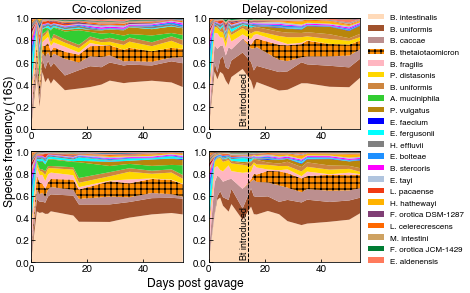

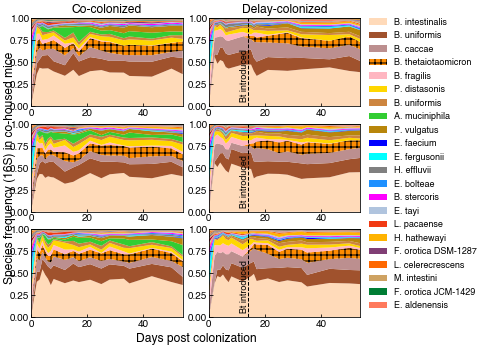

In [11]:
def muller_16s_plot(ax, times, freqs, asv_ids, colors, labels, alpha=1):
    """ freqs has dimensions of (time, bc freq).
     times and freqs.shape[0] should have same dimension. """
    cum_freqs = np.cumsum(freqs, axis=1)

    asv = asv_ids[0]
    ax.fill_between(times, np.zeros(len(times)), cum_freqs[:, 0], facecolor=colors[asv], label=labels[asv], alpha=alpha)

    for i in range(freqs.shape[1]-2):
        asv = asv_ids[i+1]
        if asv in asv_labels and asv_labels[asv] == 'B. thetaiotaomicron':
            hatch = '++'
        else:
            hatch = None
        ax.fill_between(times, cum_freqs[:, i], cum_freqs[:, i+1], facecolor=colors[asv], label=labels[asv], hatch=hatch, alpha=alpha)

    last_asv = asv_ids[-1]
    ax.fill_between(times, cum_freqs[:, freqs.shape[1]-2], cum_freqs[:, freqs.shape[1]-1], color=colors[last_asv], label=labels[last_asv], alpha=alpha)
    # ax.legend()

fig = plt.figure( figsize=(8,4.5))
gs = plt.GridSpec(2, 3, width_ratios=(1, 1, 0.6), figure=fig)
species_colors = [plot_utils.KELLY_COLORS[i%len(plot_utils.KELLY_COLORS)] for i in range(0, 56)]

asv_colors = {asvs_to_label[0]: 'peachpuff',
               asvs_to_label[1]: 'sienna',
                asvs_to_label[2]: 'rosybrown',
                  asvs_to_label[3]: 'darkorange',
                  asvs_to_label[4]: 'lightpink',
                  asvs_to_label[5]: 'gold',
                  asvs_to_label[6]: 'peru',
                  asvs_to_label[7]: 'limegreen', # akkermansia
                  asvs_to_label[8]: 'darkgoldenrod',
                  asvs_to_label[9]: 'blue',
                  asvs_to_label[10]: 'cyan',
                  asvs_to_label[11]: 'grey',
                  asvs_to_label[12]: 'dodgerblue',
                  asvs_to_label[13]: 'fuchsia',
                  asvs_to_label[14]: 'lightsteelblue'}
asv_colors = asv_colors | {asv_id: plot_utils.KELLY_COLORS[asv_id%len(plot_utils.KELLY_COLORS)] for asv_id in asv_ids if asv_id not in asv_colors}
asv_labels = {}
for asv in asv_ids:
    if asv not in asvs_to_label:
        asv_labels[asv] = ''
    else:
        species = asv_species_map[asv]
        species_items = species.strip(' ').split(' ')
        if len(species_items) == 2:
            species = f'{species_items[0][0]}' + '. ' + species_items[1]
        elif len(species_items) == 3:
            species = species_items[0][0] + '. ' + species_items[1] + ' ' + species_items[2]
        else:
            print(f'Failed to relabel {asv}: {species}')
        asv_labels[asv] = species


outer_ax = fig.add_subplot(gs[:, :2])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Days post gavage', fontsize=12, labelpad=15)
outer_ax.set_ylabel('Species frequency (16S)', fontsize=12, labelpad=15)

for m, mouse in enumerate([1, 2, 11, 12]):
    ax = fig.add_subplot(gs[m%2, m//2])

    if m == 0:
        ax.set_title('Co-colonized', fontsize=12)
    if m == 2:
        ax.set_title('Delay-colonized', fontsize=12)

    days, freqs = np.array(community_arrays[mouse]['timepoints']), np.array(community_arrays[mouse]['freqs'])
    if mouse > 10:
        ax.axvline(14, color='black', linestyle='dashed', lw=1)
        bt_intro = ax.text(11.2, 0.05, r'Bt introduced', fontsize=9, rotation=90)
        # bt_intro.set_bbox(dict(facecolor='none', edgecolor='black', linestyle='dashed'))
    muller_16s_plot(ax, days, freqs, asv_ids, asv_colors, asv_labels)

    if m == 3:
        ax.legend(bbox_transform=ax.transAxes, loc='upper left', bbox_to_anchor=(1, 2.30), ncol=1, frameon=False, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 54)

fig.savefig(f'{figures_dir}/fig5B_16s_composition.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/fig5B_16s_composition.pdf', transparent=True, bbox_inches='tight')

#### si
fig = plt.figure( figsize=(8,5.5))
gs = plt.GridSpec(3, 3, width_ratios=(1, 1, 0.6), figure=fig)

outer_ax = fig.add_subplot(gs[:, :2])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Days post colonization', fontsize=12, labelpad=15)
outer_ax.set_ylabel('Species frequency (16S) in co-housed mice', fontsize=12, labelpad=15)

for col, mice in enumerate([[3, 4, 5], [13, 14, 15]]):
    for row, mouse in enumerate(mice):
        ax = fig.add_subplot(gs[row, col])

        if row == 0 and col == 0:
            ax.set_title('Co-colonized', fontsize=12)
        if row == 0 and col == 1:
            ax.set_title('Delay-colonized', fontsize=12)

        days, freqs = np.array(community_arrays[mouse]['timepoints']), np.array(community_arrays[mouse]['freqs'])
        if mouse > 10:
            ax.axvline(14, color='black', linestyle='dashed', lw=1)
            bt_intro = ax.text(11.2, 0.07, r'Bt introduced', fontsize=9, rotation=90)
            # bt_intro.set_bbox(dict(facecolor='none', edgecolor='black', linestyle='dashed'))
        muller_16s_plot(ax, days, freqs, asv_ids, asv_colors, asv_labels)

        if row == 1 and col==1:
            ax.legend(bbox_transform=ax.transAxes, loc='upper left', bbox_to_anchor=(1, 2.30), ncol=1, frameon=False, fontsize=9)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 54)


fig.savefig(f'{figures_dir}/figS5A_16s_composition_in_cohoused.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/figS5A_16s_composition_in_cohoused.pdf', transparent=True, bbox_inches='tight')


## Fig. S5B: Community abundance comparison


/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/8661966.py:27: RuntimeWarning: divide by zero encountered in scalar divide
  or ((np.median(cohort2_final_freqs[:, i])/np.max(cohort1_final_freqs[:, i]) > 100) & (np.median(cohort2_final_freqs[:, i]) > 1e-3)):
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/8661966.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  elif ((np.median(cohort1_final_freqs[:, i])/np.max(cohort2_final_freqs[:, i]) > 100) & (np.median(cohort1_final_freqs[:, i]) > 1e-3)) \
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/8661966.py:26: RuntimeWarning: invalid value encountered in scalar divide
  elif ((np.median(cohort1_final_freqs[:, i])/np.max(cohort2_final_freqs[:, i]) > 100) & (np.median(cohort1_final_freqs[:, i]) > 1e-3)) \
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/8661966.py:27: RuntimeWarning: invalid value encountered in scalar divide
  or ((np.median(cohort2_final_

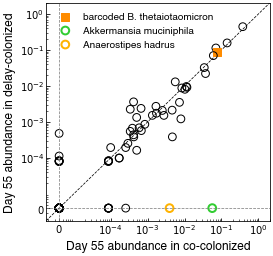

In [12]:
### sort species by mean difference in log-frequency
fig, ax = plt.subplots(figsize=(4,4))

cohort1_final_freqs = np.array( [community_arrays[m]['freqs'][-1] for m in [1,2,3,4,5]] )
cohort2_final_freqs = np.array( [community_arrays[m]['freqs'][-1] for m in [11, 12, 13, 14, 15]] )

pseudocount = 4e-6
cohort1_mean_freq = np.mean(cohort1_final_freqs + pseudocount, axis=0)
cohort2_mean_freq = np.mean(cohort2_final_freqs +  pseudocount,  axis=0)

delta_log = np.abs(np.log(cohort1_mean_freq) - np.log(cohort2_mean_freq))
argsort = np.argsort(delta_log)[::-1]

for i, asv in enumerate(asv_ids):
    rnd1, rnd2 = pseudocount, pseudocount

    x_median, xmin, xmax = np.median(cohort1_final_freqs[:, i]), np.min(cohort1_final_freqs[:, i]), np.max(cohort1_final_freqs[:, i])
    y_median, ymin, ymax = np.median(cohort2_final_freqs[:, i]), np.min(cohort2_final_freqs[:, i]), np.max(cohort2_final_freqs[:, i])

    species = asv_species_map[asv]

    if 'Bacteroides thetaiotaomicron' in species: ## B.theta
        label = 'barcoded B. thetaiotaomicron'
        ax.scatter( np.median(cohort1_final_freqs[:, i]) + rnd1, np.median(cohort2_final_freqs[:, i]) + rnd2, label=label, marker='s', color=asv_colors[asv], s=60)
    
    elif ((np.median(cohort1_final_freqs[:, i])/np.max(cohort2_final_freqs[:, i]) > 100) & (np.median(cohort1_final_freqs[:, i]) > 1e-3)) \
         or ((np.median(cohort2_final_freqs[:, i])/np.max(cohort1_final_freqs[:, i]) > 100) & (np.median(cohort2_final_freqs[:, i]) > 1e-3)):
        
        ax.scatter( np.median(cohort1_final_freqs[:, i]) + rnd1, np.median(cohort2_final_freqs[:, i]) + rnd2, edgecolors=asv_colors[asv], marker='o', facecolors='none',
                    label=species, s=60, linewidth=2)
    else:  
        ax.scatter( np.median(cohort1_final_freqs[:, i]) + rnd1, np.median(cohort2_final_freqs[:, i]) + rnd2, color='black', marker='o', facecolors='none', s=60)

ax.legend(loc=2, ncol=1, frameon=False, fontsize=10)

plot_utils.plot_diagonal(ax)
ax.set_xlim(1.8e-6, 2)
ax.set_ylim(1.8e-6, 2)
ax.set_yscale('log')
ax.set_xscale('log')
ax.axvline(pseudocount, color='grey', linestyle='dashed')
ax.axhline(pseudocount, color='grey', linestyle='dashed')

# ax.axvspan(1.5e-6, 1e-5, color='grey', alpha=0.2)
# ax.axhspan(1.5e-6, 1e-5, color='grey', alpha=0.2)
xticks = ax.get_xticks()
ticks = [pseudocount, 10**-4, 10**-3, 10**-2, 10**-1, 1]
ticklabels = [ r"$0$",
               "$10^{-4}$",
                "$10^{-3}$",
                "$10^{-2}$",
                "$10^{-1}$",
                "$10^{0}$",]
            
ax.set_xticks(ticks)
ax.set_xticklabels(ticklabels)
ax.set_yticks(ticks)
ax.set_yticklabels(ticklabels)
ax.set_xlabel('Day 55 abundance in co-colonized', fontsize=12)
ax.set_ylabel('Day 55 abundance in delay-colonized', fontsize=12)

fig.savefig(f'{figures_dir}/figS5B_16s_abundance_correlations_co_vs_delayed.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/figS5B_16s_abundance_correlations_co_vs_delayed.pdf',transparent=True, bbox_inches='tight')


## Figs. 5C–D: Barcode trajectories and diversity


In [ ]:
inoculum_strains = ["Enterocloster aldenensis", "Enterocloster bolteae", "Lacrimispora celerecrescens", 
                    "Enterocloster citroniae", "Enterocloster clostridioformis", "Hungatella hathewayi", 
                    "[Clostridium] hylemonae", "Clostridium innocuum", "Faecalicatena orotica DSM-1287",
                    "Faecalicatena orotica JCM-1429", "Clostridium scindens", "Clostridium symbiosum",
                    "Akkermansia muciniphila", "Anaerostipes hadrus", "Bacteroides caccae", 
                    "Bacteroides fragilis", "Bacteroides intestinalis", "Bacteroides stercoris", 
                    "Bacteroides uniformis", "Phocaeicola vulgatus", "Blautia producta", 
                    "Drancourtella massiliensis", "Eggerthella lenta", "Eisenbergiella tayi", 
                    "Enterococcus casseliflavus", "Enterococcus faecium", "Enterococcus faecium",
                    "Erysipelatoclostridium ramosum", "Escherichia fergusonii", "Flavonifractor plautii" ,
                    "Hungatella effluvii", "Klebsiella variicola", "Lachnoclostridium pacaense",
                    "Murimonas intestini", "Parabacteroides distasonis"]
## focus only on ASVs called by DADA that were nominally in the community inoculum
inoculum_indices = []
for strain in inoculum_strains:
    inoculum_indices.append( np.where(species_identities == strain)[0][0] )
inoculum_indices = np.array(inoculum_indices)

bool_late = np.zeros(len(inoculum_indices))
bool_final = np.zeros(len(inoculum_indices))

bool_1e3 = np.zeros(len(inoculum_indices))
bool_1e4 = np.zeros(len(inoculum_indices))

for m, mouse in enumerate([1,2,3,4,5, 11, 12, 13, 14, 15]):
    # print(f'MOUSE {mouse}')
    days = np.array(community_arrays[mouse]['timepoints'])
    z = np.where( days >= 14)[0][0]

    z_late = np.where(days >= 40)[0][0]

    init_freqs = community_arrays[mouse]['freqs'][1:z]
    late_freqs = np.array(community_arrays[mouse]['freqs'][z:])
    final_freqs = np.array(community_arrays[mouse]['freqs'][z_late:])

    bool_1e3 += ((late_freqs[:, inoculum_indices]>1e-3).sum(axis=0) > 1)
    bool_1e4 += ((late_freqs[:, inoculum_indices]>1e-4).sum(axis=0) > 1)

print('Num species (excl. B.theta0) at >1e-3 consistently after day 14 in a majority of mice =', (bool_1e3 > 5).sum())
print('Num species (excl. B.theta0) at >1e-4 consistently after day 14 in a majority of mice =', (bool_1e4 > 5).sum())

Num species (excl. B.theta0) at >1e-3 consistently after day 14 in a majority of mice = 26
Num species (excl. B.theta0) at >1e-4 consistently after day 14 in a majority of mice = 32


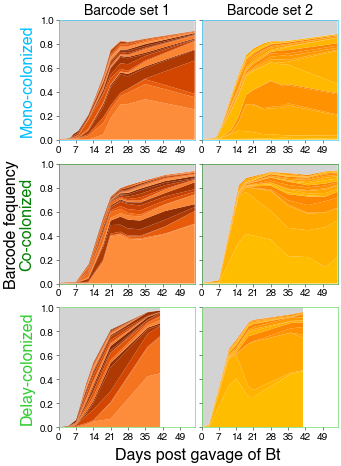

In [13]:
expt = 'E2'
fig = plt.figure(figsize=(5, 7.5))
gs = plt.GridSpec(nrows=3, ncols=2, figure=fig, wspace=0.05)
outer_ax = fig.add_subplot(gs[:, :])
outer_ax.set_xlabel('Days post gavage of Bt', fontsize=16, labelpad=20)
outer_ax.set_ylabel('Barcode fequency', fontsize=16, labelpad=40)
plot_utils.turn_off_ax(outer_ax)



for row, (m_set, condition_color, label) in enumerate(zip([[6, 7], [1, 2], [11, 12]], ['deepskyblue', 'green', 'limegreen'], ['Mono-colonized', 'Co-colonized', 'Delay-colonized'] )):
    for col, (mouse, bc_colors) in enumerate( zip(m_set, ['Oranges', 'Wistia']) ):
        large_indices = shared.find_large_barcodes(expt, [mouse], max_cutoff=1e-2, final_cutoff=2)

        order_tuple = shared.order_barcodes_by_pool(large_indices, shared.barcode_pool_assignments, 
                                                    [('S1', 'Oranges'), ('S2', 'Wistia'), ('S3', 'Blues'), 
                                                     ('S4', 'Purples'), ('E2_shared', 'Greys'), ('E2_ambiguous', 'Greys')], cg_at_end=False, cg_all_low_freqs=True)

        ordered_indices, ordered_colors = order_tuple
        days, freqs = shared.make_muller_freqs(expt, mouse, ordered_indices, 18, min_depth=10**4, include_pseudo_derepped=True, include_reseq=True)
        if row == 2: ## offset delay-colonized t to time since gavage of Bt
            days -= 14
        ax = fig.add_subplot(gs[row, col])
        shared.muller_plot(ax, days, ordered_indices, freqs, ordered_colors)

        ax.set_ylim(0, 1)
        ax.set_xlim(0, 55)

        ax.set_xticks([0, 7, 14, 21, 28, 35, 42, 49])


        for spine in ['bottom', 'top', 'right', 'left']:
            ax.spines[spine].set_color(condition_color)
            ax.spines[spine].set_linewidth(0.5)
        ax.tick_params(axis='x', direction='out', width=0.5, length=3)
        ax.tick_params(axis='y', direction='out', width=0.5, length=3)
        
        if row == 0:
            ax.set_title(f'Barcode set {col+1}', fontsize=14)
        if col == 1:
            ax.set_yticklabels([])
        if col == 0:
            ax.set_ylabel(label, fontsize=16, color=condition_color, labelpad=+5, ha='center')

fig.savefig(f'{figures_dir}/fig5C_comm_muller.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/fig5C_comm_muller.pdf', transparent=True, bbox_inches='tight')


## Figs. S5C–D: Barcode richness and mean fold-change dynamics


Num barcodes considered for lfc calculation in Set 1 col., mouse 6: 7771
	Barcode freq ranges: 2.6e-05 - 1.2e-03
Num barcodes considered for lfc calculation in Set 1 col., mouse 1: 7771
	Barcode freq ranges: 2.6e-05 - 1.2e-03
Num barcodes considered for lfc calculation in Set 1 col., mouse 11: 7984
	Barcode freq ranges: 2.2e-05 - 8.2e-04
Num barcodes considered for lfc calculation in Set 2 col., mouse 7: 7644
	Barcode freq ranges: 2.0e-05 - 1.1e-03
Num barcodes considered for lfc calculation in Set 2 col., mouse 2: 7644
	Barcode freq ranges: 2.0e-05 - 1.1e-03
Num barcodes considered for lfc calculation in Set 2 col., mouse 12: 7917
	Barcode freq ranges: 1.5e-05 - 1.1e-03


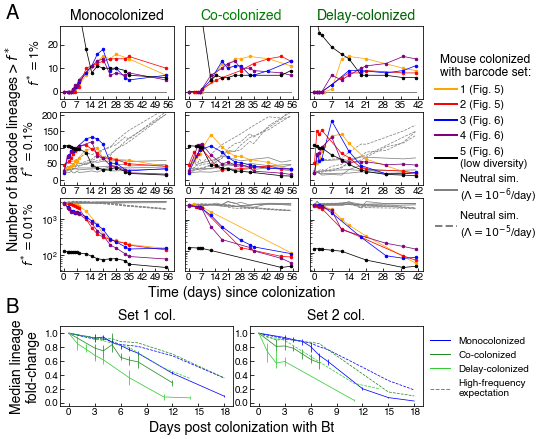

In [ ]:
fig = plt.figure(figsize=(6.5, 7))
gs = plt.GridSpec(5,3, figure=fig, height_ratios=[1, 1, 1, 0.4, 1.1], wspace=0.1)
legend_ax = fig.add_subplot(gs[:])
plot_utils.turn_off_ax(legend_ax)
legend_markers = [ mpl.lines.Line2D((0,), (0,), color='orange',  linestyle='solid', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='red', linestyle='solid', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='blue', linestyle='solid', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='purple', linestyle='solid', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='black', linestyle='solid', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='grey', linestyle='solid', lw=2),
                    mpl.lines.Line2D((0,), (0,), color='grey', linestyle='dashed', lw=2), ]


outer_ax = fig.add_subplot(gs[:3, :])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_ylabel(r'Number of barcode lineages > $f^*$', fontsize=14, labelpad=35)
outer_ax.set_xlabel(r'Time (days) since colonization', fontsize=14, labelpad=15)
outer_ax.legend(legend_markers, ['1 (Fig. 5)', '2 (Fig. 5)', '3 (Fig. 6)', '4 (Fig. 6)', '5 (Fig. 6)\n(low diversity)', 
                                 'Neutral sim.\n($\Lambda=10^{-6}$/day)', 'Neutral sim.\n($\Lambda=10^{-5}$/day)'],
          title="Mouse colonized\nwith barcode set:", title_fontsize=12,
          loc=(1.02, 0.1), frameon=False, fontsize=11, ncol=1,
          handletextpad=0.3, bbox_transform=legend_ax.transAxes)
outer_ax.text(-0.15, 1.03, 'A', fontsize=20)

axs = np.array([[fig.add_subplot(gs[row, col]) for col in range(3)] for row in range(3)])



E2_mouse_colors = {1:'orange', 2:'red', 3:'blue', 4:'purple', 5:'black',
                    6:'orange', 7:'red', 8:'blue', 9:'purple', 10:'black',
                    11:'orange', 12:'red', 13:'blue', 14:'purple', 15:'black'}
            
for col, (mice, label, color) in enumerate(zip([[6,7, 8, 9, 10], [1,2,3,4, 5], [11, 12, 13, 14, 15]],
                                                   ['Monocolonized', 'Co-colonized', 'Delay-colonized'],
                                                   ['black', 'green', 'darkgreen'])):
    cutoffs = np.array([1e-2, 1e-3, 1e-4])
    min_depth = 10**4
    for mouse in mice:
        # min_depth = np.min([10**4, 3 * cutoffs**-1.]) # discard low depth samples where counts cannot be reliably estimated
        days_by_cutoffs, n_barcodes_by_cutoff = shared.estimate_num_barcodes_above_cutoff(
            'E2', mouse, cutoffs, min_depth=min_depth)
        
        sim_days_Nt6, sim_n_barcodes_by_cutoff_Nt6 = shared.estimate_num_barcodes_above_cutoff_simulated(
            'E2', mouse, cutoffs, Ntau=10**6, min_depth=min_depth)

        sim_days_Nt5, sim_n_barcodes_by_cutoff_Nt5 = shared.estimate_num_barcodes_above_cutoff_simulated(
            'E2', mouse, cutoffs, Ntau=10**5, min_depth=min_depth)

        for row, (cutoff, cutoff_label) in enumerate(zip([1e-2, 1e-3, 1e-4], ['1%', '0.1%', '0.01%'])):
            days = days_by_cutoffs[row]
            n_barcodes_above_cutoff = n_barcodes_by_cutoff[row]

            sim_days_6 = sim_days_Nt6[row]
            sim_n_barcodes_above_cutoff_Nt6 = sim_n_barcodes_by_cutoff_Nt6[row]
            sim_days_5 = sim_days_Nt5[row]
            sim_n_barcodes_above_cutoff_Nt5 = sim_n_barcodes_by_cutoff_Nt5[row]


            ax = axs[row,col]
            
            if label == 'Delay-colonized':
                days -= 14
                sim_days_6 -= 14
                sim_days_5 -= 14
            ax.plot(days, n_barcodes_above_cutoff, marker='.', markersize=5, color=E2_mouse_colors[mouse], linestyle='solid', label=f'set {mouse-5}')

            if mouse % 5 != 0:
                ax.plot(sim_days_6, sim_n_barcodes_above_cutoff_Nt6, color='grey', zorder=0)
                ax.plot(sim_days_5, sim_n_barcodes_above_cutoff_Nt5, color='grey', linestyle='dashed', zorder=0)

### formatting ##
for row, (cutoff, cutoff_label) in enumerate(zip([1e-2, 1e-3, 1e-4], ['1%', '0.1%', '0.01%'])):
    for col, (mice, label, color) in enumerate(zip([[6,7, 8, 9, 10], [1,2,3,4, 5], [11, 12, 13, 14, 15]],
                                                   ['Monocolonized', 'Co-colonized', 'Delay-colonized'],
                                                   ['black', 'green', 'darkgreen'])):
        ax = axs[row,col]
        if row == 0: 
            ax.set_title(label, color=color, fontsize=14)
        if col == 0:
            ax.set_ylabel(r'$f^*=$' + f'{cutoff_label}', fontsize=12)

        ax.set_xlim(-2, 59)
        ax.set_xticks([0, 7, 14, 21, 28, 35, 42, 49, 56])
        ax.set_xticklabels([0, 7, 14, 21, 28, 35, 42, 49, 56], fontsize=10)

        if row == 2:
            ax.set_yscale('log')
        if row == 0:
            ax.set_ylim(-3, 28)
            ax.set_yticks([0, 10, 20])
        if row == 1:
            ax.set_ylim(-15, 210)
            ax.set_yticks([0, 50, 100, 150, 200])
        if row == 2:
            ax.set_yscale('log')
            ax.set_yticks([10**2, 10**3])
        if col != 0:
            ax.set_yticklabels([])
        if col == 2:
            ax.set_xlim([-2, 44])
            ax.set_xticks([0, 7, 14, 21, 28, 35, 42])
        else:
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)



    
## median fold change
mfc_gs = mpl.gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[-1, :], wspace=0.1, hspace=0.1)
mfc_outer = fig.add_subplot(gs[-1, :])
plot_utils.turn_off_ax(mfc_outer)
mfc_outer.set_xlabel('Days post colonization with Bt', fontsize=14, labelpad=15)
mfc_outer.set_ylabel('Median lineage\nfold-change', fontsize=14, labelpad=20)
mfc_outer.text(-0.15, 1.17, 'B', fontsize=20)

min_freq = 0
Ntau = 10**5 #days
MIN_GROUP_SIZE = 30

mice_in_each_col = [[6,1,11], [7, 2, 12]]
mouse_colors = {6:'blue', 7:'blue', 1:'forestgreen', 2:'forestgreen', 11:'limegreen', 12:'limegreen'}
for z, (m_set, inoc_bool, title) in enumerate( zip(mice_in_each_col,
                                        [shared.barcode_pool_assignments['S1'][1], shared.barcode_pool_assignments['S2'][1]], 
                                        ['Set 1 col.', 'Set 2 col.']) ):
    ax = fig.add_subplot(mfc_gs[z])
    for m, mouse in enumerate(m_set):
        ## Group barcodes by initial frequency for fold-change plot
        day0 = 0 if mouse < 10 else 14
        plot_days, mouse_reads, mouse_depths = shared.get_mouse_timecourse('E2', mouse)
        mouse_freqs = shared.calc_freqs(mouse_reads, mouse_depths)
        
        barcode_groups = []
        barcode_ranges = []
        neutral_sim_frequencies = sim.neutral_sim(mouse_freqs[0], Ntau, plot_days, mouse_depths)

        # high freq. expectation
        max_freqs = np.max(mouse_freqs, axis=0)
        high_frequency_barcodes = np.where(max_freqs > 1e-2)[0]
        high_frequency_expected_freqs = shared.high_frequency_expectation(plot_days, mouse_freqs, high_frequency_barcodes, mouse_depths, Ntau=Ntau, min_day=day0) 


        day0_reads = mouse_reads[0]
        day0_freqs = mouse_freqs[0]
        # lower = MIN_READS
        lower = np.percentile(day0_reads[inoc_bool][day0_reads[inoc_bool] > 0], 50)
        max_reads = np.percentile(day0_reads[inoc_bool][day0_reads[inoc_bool] > 0], 99.9)
        upper = lower * 1.1
        while upper < max_reads:
            indices = np.where( (day0_reads >= lower) & (day0_reads < upper) )[0]
            if len(indices) < MIN_GROUP_SIZE:
                upper *= 1.1
                continue
            barcode_ranges.append( (lower, upper) )
            lower = upper
            upper = lower * 1.1
            barcode_groups.append(indices)
            
        print( f'Num barcodes considered for lfc calculation in {title}, mouse {mouse}:', np.sum([len(g) for g in  barcode_groups]) )
        print( f"\tBarcode freq ranges: {np.min(barcode_ranges)/day0_reads.sum():.1e} - {np.max(barcode_ranges)/day0_reads.sum():.1e}" )
        for freqs, color, ls in zip([high_frequency_expected_freqs, mouse_freqs], 
                                    [mouse_colors[mouse], mouse_colors[mouse]], ['dashed', 'solid']):

            median_lfcs = shared.calc_median_lfc(freqs, mouse_depths, barcode_groups=barcode_groups)
            x, y, yerr = [day0], [1], [[0, 0]]
            for day, depth, median_lfcs_in_groups in zip(plot_days[1:], mouse_depths[1:], median_lfcs):
                # have enough separate freq ranges, enough depth, and not too late to avoid low barcode count
                if len(median_lfcs_in_groups) < 4 or depth < 2*10**3 or day-day0 > 18:
                    continue
                
                medians = [median for (median, group_lfcs) in median_lfcs_in_groups]
                lfcs = [group_lfcs for (median, group_lfcs) in median_lfcs_in_groups]

                median_of_medians = np.exp(np.median(medians))
                quartiles = np.exp([np.percentile(medians, 25), np.percentile(medians, 75)])
                deltas = [median_of_medians- quartiles[0], quartiles[1] - median_of_medians]

                x.append(day)
                y.append(median_of_medians)
                yerr.append(deltas)

            x = np.array(x)
            if ls == 'dashed': # high frequency expectation
                yerr = 0
            ax.errorbar(x-day0, y, yerr=np.transpose(yerr), color=color, ls=ls)

    if 'format':
        ax.set_title(title, fontsize=14)
        ax.set_ylim(-0.05, 1.1)
        ax.set_xlim(-1, 19)
        ax.set_xticks([0,3,6,9,12,15,18])
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
        ax.set_xticklabels([0,3,6,9,12,15,18], fontsize=10)

legend_markers = [ mpl.lines.Line2D((0,), (0,), color=c,  linestyle='solid', lw=1) for c in ['blue', 'forestgreen', 'limegreen']]  \
                    + [mpl.lines.Line2D((0,), (0,), color='grey', linestyle='dashed', lw=1)]
ax.legend(legend_markers, ['Monocolonized', 'Co-colonized', 'Delay-colonized', 'High-frequency\nexpectation'], 
          loc=(1.02, 0.05), bbox_transform=ax.transAxes, fontsize=10, frameon=False)

fig.savefig(f'{figures_dir}/figS5CD_si_num_barcodes_detected.svg')
fig.savefig(f'{figures_dir}/figS5CD_si_num_barcodes_detected.pdf')


## Figs. 5D–G: Cross-environment fitness comparisons


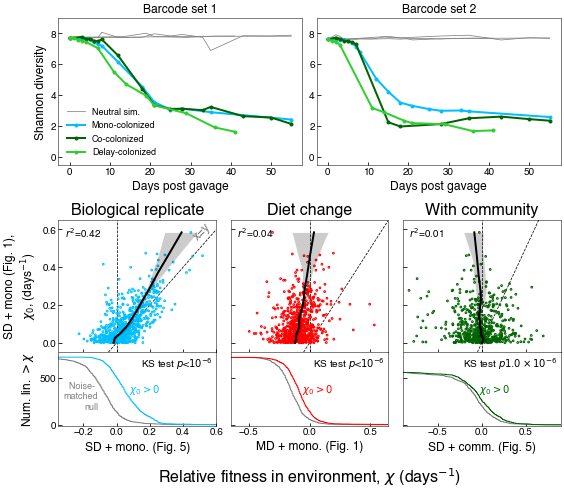

In [9]:
with open(f'{pickled_dir}/vivo_fitness_dict.pkl', 'rb') as f: ## requires running 5a_make_jdfe_arrays.ipynb
    invivo_fitness_dict = pickle.load(f)

#### MASTER FIGURE ####
fig = plt.figure(figsize=(9, 7.5))
gs = plt.GridSpec(nrows=4, ncols=6, height_ratios=(2, 0.75, 1.8,1), hspace=0, figure=fig, wspace=0.2)


### ENTROPY PLOTS ####
plot_sets = [
              ([(6,), (1,), (11,)], ['deepskyblue', 'darkgreen', 'limegreen'],
               ['E2', 'E2', 'E2'], ['Mono-colonized', 'Co-colonized', 'Delay-colonized']),
              ([(7,), (2,), (12,)], ['deepskyblue', 'darkgreen', 'limegreen'],
               ['E2', 'E2', 'E2'], ['Mono', 'Comm', 'Delay']),
]
min_freq = 1e-4
# entropy_ax = fig.add_subplot(gs[0, 3*0:3*(0+1)])
for c, (mice_sets, colors, expts, labels) in enumerate(plot_sets):
    entropy_ax = fig.add_subplot(gs[0, 3*c:3*(c+1)])

    linestyle='solid'
    # if c == 1:
    #     linestyle='dashed'
    for z, (m_set, colors, expt, label) in enumerate( zip(mice_sets, colors, expts, labels) ):
        for mouse in m_set:
            plot_days, mouse_reads, mouse_depths = shared.get_mouse_timecourse(expt, mouse)
            if mouse > 10:
                plot_days -= 14
            mouse_freqs = shared.calc_freqs(mouse_reads, mouse_depths)


            mouse_large_entropies = shared.calc_entropy(mouse_freqs, min_freq=min_freq)

            neutral_sim_frequencies = sim.neutral_sim(mouse_freqs[0], 10**6, plot_days, mouse_depths)
            expected_neutral_entropies = shared.calc_entropy(neutral_sim_frequencies, min_freq=min_freq)

            neut_label = ''
            if c == 0 and z == 0:
                neut_label = 'Neutral sim.'
            entropy_ax.plot(plot_days[:], expected_neutral_entropies, color='grey', linestyle=linestyle, label=neut_label, zorder=0)

            entropy_ax.plot(plot_days, mouse_large_entropies, color=colors, label=label, linestyle=linestyle, marker='.', lw=2)

    if c == 0:
        entropy_ax.set_ylabel('Shannon diversity', fontsize=12)
        entropy_ax.set_title('Barcode set 1', fontsize=12)
        entropy_ax.legend(loc=3, frameon=False, fontsize=9)
    else:
        entropy_ax.set_title('Barcode set 2', fontsize=12)

    entropy_ax.set_ylim(-0.5, 9)
    entropy_ax.set_xlabel('Days post gavage', fontsize=12)

    for spine in ['top', 'right', 'left', 'bottom']:
        entropy_ax.spines[spine].set_linewidth(0.5)

### JDFE ###
cumulative = True
log = False
plot_mean = False

outer_ax = fig.add_subplot(gs[3, :])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Relative fitness in environment, $\chi$ (days$^{-1}$)', labelpad=40, fontsize=16)
SD_SD_ax = fig.add_subplot(gs[2, 0:2])
SD_cdf_ax = fig.add_subplot(gs[3, 0:2])
SD_MD_ax = fig.add_subplot(gs[2, 2:4])
MD_cdf_ax = fig.add_subplot(gs[3, 2:4])
SD_comm_ax = fig.add_subplot(gs[2, 4:6])
comm_cdf_ax = fig.add_subplot(gs[3, 4:6])


for label, scatter_ax, cdf_ax, color, (lfc_x, lfc_y, null) in zip(
        ['SD + mono. (Fig. 5)', 'MD + mono. (Fig. 1)', 'SD + comm. (Fig. 5)', ''],
        [SD_SD_ax, SD_MD_ax, SD_comm_ax, SD_comm_ax],
        [SD_cdf_ax, MD_cdf_ax, comm_cdf_ax, comm_cdf_ax],
        ['deepskyblue', 'red', 'darkgreen', 'limegreen'],
        [('SD2', 'SD1', 'SD2_null'),
         ('MD', 'SD1', 'MD_null'),
         ('comm', 'SD1', 'comm_null')]):

    lfcs_x = np.array(invivo_fitness_dict[lfc_x])
    lfcs_y = np.array(invivo_fitness_dict[lfc_y])
    null = np.array(invivo_fitness_dict[null])


    valid = (~np.isnan(lfcs_x))*(~np.isnan(null))*(lfcs_x != 0)*(null != 0) #exclude 
    r = scipy.stats.pearsonr(lfcs_x[valid], lfcs_y[valid])[0]
    scatter_ax.scatter(lfcs_x[valid], lfcs_y[valid], color=color, s=3, marker='o', facecolor='none')
    scatter_ax.text(0.04, 0.96, f"$r^2$={r**2:.2f}", transform=scatter_ax.transAxes, fontsize=10, ha='left', va='top')

    if 'lowess':
        lowess_x, lowess_y = lfcs_x[valid], lfcs_y[valid]
        lowess_fit = sm.nonparametric.lowess(lowess_x, lowess_y, frac=0.40)
        scatter_ax.plot(lowess_fit[:, 1], lowess_fit[:, 0], color='black', lw=2)

        y_values_to_evaluate = np.linspace(0, np.max(lowess_y), 100)
        

        zip_lfcs = np.array(list(zip(lowess_x, lowess_y)))
        n_bootstraps = 100
        lowess_bootstraps = np.zeros((n_bootstraps, len(y_values_to_evaluate)))
        for i in range(n_bootstraps):
            bootstrapped_data = rnd.choice(zip_lfcs, size=len(zip_lfcs), replace=True)
            
            bootstrapped_lowess = sm.nonparametric.lowess(bootstrapped_data[:, 0], bootstrapped_data[:, 1], frac=0.30, xvals=y_values_to_evaluate)
            lowess_bootstraps[i] = bootstrapped_lowess
        
        upper_percentile = np.percentile(lowess_bootstraps, 97.5, axis=0)
        lower_percentile = np.percentile(lowess_bootstraps, 2.5, axis=0)
        scatter_ax.fill_betweenx(y_values_to_evaluate, lower_percentile, upper_percentile, color='black', lw=0, alpha=0.2)


    if cumulative:
        binspace=np.linspace(-2, 2, 641)
        cdf_ax.hist(null[valid], bins=binspace, histtype='step', color='grey', cumulative=-1, log=log, label='Null')
        cdf_ax.hist(lfcs_x[valid], bins=binspace, histtype='step', color=color, cumulative=-1, log=log, label='(SD+mono.)-fit')
        cdf_ax.set_ylim(-10, 850)
    else:
        binspace=np.linspace(-1, 1, 81)
        cdf_ax.hist(null[valid], bins=binspace, histtype='step', color='grey', log=log, label='Null')
        cdf_ax.hist(lfcs_x[valid], bins=binspace, histtype='step', color=color, log=log, label='(SD+mono.)-fit')
        cdf_ax.set_ylim(-20, 95)

    _, ks_pval = scipy.stats.kstest(np.array(lfcs_x)[valid], np.array(null)[valid])
    if ks_pval < 1e-6: pval_text='$p$<'+ f'$10^{{{-6}}}$'
    elif ks_pval < 0.01: pval_text=f'$p$' +f'${plot_utils.as_si(10**-6,1)}$'
    else: pval_text=f'p={ks_pval:.0e}'
    cdf_ax.text(0.98, 0.95, f'KS test {pval_text}', transform=cdf_ax.transAxes, fontsize=10, ha='right', va='top')
    cdf_ax.set_xlabel(label, fontsize=12)

    if plot_mean:
        cdf_ax.axvline( np.median(np.array(lfcs_x)[valid]), color=color, zorder=10, lw=1.5)
        cdf_ax.axvline( np.median(np.array(null)[valid]), color='grey', zorder=0, lw=1.5)

SD_SD_ax.text(0.98, 0.83, 'x=y', transform=SD_SD_ax.transAxes, color='grey', fontsize=12, ha='right', va='bottom', rotation=45)


for (ax, cdf_ax, title, color, xlims) in zip([SD_SD_ax, SD_MD_ax, SD_comm_ax],
                               [SD_cdf_ax, MD_cdf_ax, comm_cdf_ax],
                               ['Biological replicate', 'Diet change', 'With community'],
                               ['deepskyblue', 'red', 'darkgreen'],
                               [(None, None), (-0.6, 0.6), (None, None)]):
    plot_utils.plot_diagonal(ax)
    ax.axvline(0, color='black', linestyle='dashed', zorder=0)
    ax.set_ylim(-0.05, 0.65)
    cdf_ax.set_ylim(-10, 780)

    if title == 'Biological replicate':
        cdf_ax.set_xlim(-0.35, 0.6)
        ax.set_xlim(-0.35, 0.6)
        cdf_ax.text(0.45, 0.5, "$\chi_0>0$", color='deepskyblue', transform=cdf_ax.transAxes, fontsize=10, ha='left', va='center')
    elif title == 'Diet change':
        cdf_ax.set_xlim(-0.65, 0.65)
        ax.set_xlim(-0.65, 0.65)
        cdf_ax.text(0.45, 0.5, "$\chi_0>0$", color='red', transform=cdf_ax.transAxes, fontsize=10, ha='left', va='center')
    elif title == 'With community':
        cdf_ax.set_xlim(-0.9, 0.9)
        ax.set_xlim(-0.9, 0.9)
        cdf_ax.text(0.48, 0.5, "$\chi_0>0$", color='darkgreen', transform=cdf_ax.transAxes, fontsize=10, ha='left', va='center')

    ax.set_xticklabels([])
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_linewidth(0.5)
        cdf_ax.spines[spine].set_linewidth(0.5)

    ax.set_title(title, fontsize=16)
    if ax != SD_SD_ax:
        ax.set_yticklabels([])
        cdf_ax.set_yticklabels([])
    else:
        ax.set_ylabel('SD + mono (Fig. 1),\n$\chi_0$, (days$^{-1}$)', fontsize=12)
        cdf_ax.set_ylabel('Num. lin. $>\chi$', fontsize=12)
        cdf_ax.text(0.25, 0.4, "Noise- \nmatched\nnull", color='grey', transform=cdf_ax.transAxes, fontsize=9, ha='right', va='center')


fig.savefig(f'{figures_dir}/fig5D-G_invivo_jdfe.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/fig5D-G_invivo_jdfe.pdf', transparent=True, bbox_inches='tight')


## Fig. S6A

SD + mono. (cohort 1) vs SD + mono. (cohort 2): n_barcodes=9829
PearsonRResult(statistic=0.6656072677768412, pvalue=0.0)
SignificanceResult(statistic=0.6283968906616261, pvalue=0.0)


SD + mono. (cohort 1) vs MD + mono.: n_barcodes=8886
PearsonRResult(statistic=0.16587447051384752, pvalue=7.644248716722618e-56)
SignificanceResult(statistic=0.1892039245394811, pvalue=2.106284105689415e-72)


Community co-colonized vs SD + mono. (cohort 2): n_barcodes=3416
PearsonRResult(statistic=0.07058244246066565, pvalue=3.644378688204374e-05)
SignificanceResult(statistic=0.07251242677949948, pvalue=2.2140281121739628e-05)


Community co-colonized vs Bt delay-colonized: n_barcodes=3060
PearsonRResult(statistic=0.27456870192310656, pvalue=4.687549649349393e-54)
SignificanceResult(statistic=0.25763309442147747, pvalue=1.380558491833205e-47)




/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/3660006167.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/3660006167.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/3660006167.py:137: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
/var/folders/x3/8f6xdlhn4hscmskkzs52dycc0000gn/T/ipykernel_20911/3660006167.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using 

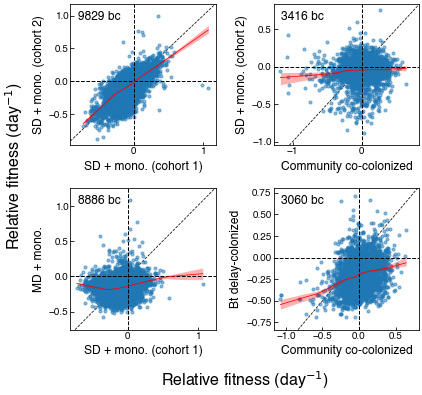

In [10]:
## takes a few minutes to produce
SD1_m, SD1_t1, SD1_t2 = 6, 2, 9
SD2_m, SD2_t1, SD2_t2 = 7, 3, 8
SD_MIN_FC = 0
MD_t1, MD_t2 = 2, 9
comm_t1, comm_t2 = 3, 8 
delay_t1, delay_t2 = 16, 25

P1_bool = shared.barcode_pool_assignments['P1'][1]
S1_bool = shared.barcode_pool_assignments['S1'][1]
S2_bool = shared.barcode_pool_assignments['S2'][1]

SD1_f1, SD1_D1 = shared.cage_avg_freqs('E1', [6, 7, 8, 9, 10], SD1_t1)
SD1_f2, SD1_D2 = shared.cage_avg_freqs('E1', [6, 7, 8, 9, 10], SD1_t2)
SD1_data = (SD1_f1, SD1_f2, SD1_D1, SD1_D2, 7)

MD_f1, MD_D1 = shared.cage_avg_freqs('E1', [11, 12, 13], MD_t1)
MD_f2, MD_D2 = shared.cage_avg_freqs('E1', [11, 12, 13], MD_t2)
MD_data = (MD_f1, MD_f2, MD_D1, MD_D2, 7)

SD2_S1_f1, SD2_S1_D1 = shared.cage_avg_freqs('E2', [6], SD2_t1)
SD2_S1_f2, SD2_S1_D2 = shared.cage_avg_freqs('E2', [6], SD2_t2)
SD2_S1_data = (SD2_S1_f1, SD2_S1_f2, SD2_S1_D1, SD2_S1_D2, 5)

SD2_S2_f1, SD2_S2_D1 = shared.cage_avg_freqs('E2', [7], SD2_t1)
SD2_S2_f2, SD2_S2_D2 = shared.cage_avg_freqs('E2', [7], SD2_t2)
SD2_S2_data = (SD2_S2_f1, SD2_S2_f2, SD2_S2_D1, SD2_S2_D2, 5)

comm_S1_f1, comm_S1_D1 = shared.cage_avg_freqs('E2', [1], comm_t1)
comm_S1_f2, comm_S1_D2 = shared.cage_avg_freqs('E2', [1], comm_t2)
comm_S1_data = (comm_S1_f1, comm_S1_f2, comm_S1_D1, comm_S1_D2, 5)

comm_S2_f1, comm_S2_D1 = shared.cage_avg_freqs('E2', [2], comm_t1)
comm_S2_f2, comm_S2_D2 = shared.cage_avg_freqs('E2', [2], comm_t2 - 1) # day 7 for community set2, no sampling day 8
comm_S2_data = (comm_S2_f1, comm_S2_f2, comm_S2_D1, comm_S2_D2, 4)

delay_S1_f1, delay_S1_D1 = shared.cage_avg_freqs('E2', [11], delay_t1)
delay_S1_f2, delay_S1_D2 = shared.cage_avg_freqs('E2', [11], delay_t2)
delay_S1_data = (delay_S1_f1, delay_S1_f2, delay_S1_D1, delay_S1_D2, 9)

delay_S2_f1, delay_S2_D1 = shared.cage_avg_freqs('E2', [12], delay_t1)
delay_S2_f2, delay_S2_D2 = shared.cage_avg_freqs('E2', [12], delay_t2)
delay_S2_data = (delay_S2_f1, delay_S2_f2, delay_S2_D1, delay_S2_D2, 9)


plotting_data = {} 
for z, (x_condition, y_condition, data) in enumerate([
    ('SD1', 'SD2', [(SD1_data, SD2_S1_data, P1_bool & S1_bool), (SD1_data, SD2_S2_data, P1_bool & S2_bool)]),
    ('SD1', 'MD', [(SD1_data, MD_data, P1_bool)]),
    ('comm', 'SD2', [(comm_S1_data, SD2_S1_data, S1_bool), (comm_S2_data, SD2_S2_data, S2_bool)]),
    ('comm', 'delay', [(comm_S1_data, delay_S1_data, S1_bool), (comm_S2_data, delay_S2_data, S2_bool)])]):

    x_lfcs, y_lfcs = [], []
    for (x_data, y_data, barcode_bool) in data:
        x_f1, x_f2, x_D1, x_D2, x_dt = x_data
        y_f1, y_f2, y_D1, y_D2, y_dt = y_data

        x_cutoff, y_cutoff = 5/x_D1, 5/y_D1
        valid = (x_f1 > x_cutoff) * (y_f1 > y_cutoff) * barcode_bool

        x1, x2 = shared.maxmin_freqs(x_f1, x_D1, x_f2, x_D2)
        y1, y2 = shared.maxmin_freqs(y_f1, y_D1, y_f2, y_D2)
        x_lfc = np.log(x2[valid] / x1[valid]) / x_dt
        y_lfc = np.log(y2[valid] / y1[valid]) / y_dt
        x_lfcs.extend(x_lfc)
        y_lfcs.extend(y_lfc)
        sub = (x_lfc < 0) & (y_lfc < 0)

    x_lfc, y_lfc = np.array(x_lfcs), np.array(y_lfcs)
    valid = (x_lfc !=0) & (y_lfc != 0)
    x_lfc, y_lfc = x_lfc[valid], y_lfc[valid]

    ## LOWESS FIT + BOOTSTRAP
    x_values_to_evaluate = np.linspace(np.min(x_lfc), np.max(x_lfc), 100)
    lowess_fit = lowess(y_lfc, x_lfc, frac=0.4)
    
    zip_lfcs = np.array(list(zip(x_lfc, y_lfc)))
    n_bootstraps = 10
    lowess_bootstraps = np.zeros((n_bootstraps, len(x_values_to_evaluate)))
    for i in range(n_bootstraps):
        bootstrapped_data = rnd.choice(zip_lfcs, size=len(zip_lfcs), replace=True)
        bootstrapped_lowess = lowess(bootstrapped_data[:, 1], bootstrapped_data[:, 0], frac=0.4, xvals=x_values_to_evaluate)
        lowess_bootstraps[i] = bootstrapped_lowess

    upper_percentile = np.percentile(lowess_bootstraps, 95, axis=0)
    lower_percentile = np.percentile(lowess_bootstraps, 5, axis=0)
    plotting_data[z] = {'labels':(x_condition, y_condition), 
                        'data':data, 
                        'lfcs':(x_lfc, y_lfc), 
                        'lowess':lowess_fit, 
                        'lowess_bootstrap':(x_values_to_evaluate, lowess_bootstraps)}


fig = plt.figure(figsize=(6.25,6))
gs = mpl.gridspec.GridSpec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], hspace=0.3, wspace=0.4)
outer_ax = fig.add_subplot(gs[:, :])
plot_utils.turn_off_ax(outer_ax)
outer_ax.set_xlabel('Relative fitness (day$^{-1}$)', fontsize=16, labelpad=40)
outer_ax.set_ylabel('Relative fitness (day$^{-1}$)', fontsize=16, labelpad=45)

labels = {'SD1':'SD + mono. (cohort 1)', 
          'SD2': 'SD + mono. (cohort 2)', 
          'MD':'MD + mono.', 
          'comm':'Community co-colonized', 
          'delay':'Bt delay-colonized'}

for z, plot_data in plotting_data.items():
    x_condition, y_condition = plot_data['labels']
    data = plot_data['data']
    x_lfc, y_lfc = plot_data['lfcs']
    lowess_fit = plot_data['lowess']
    x_values_to_evaluate, lowess_bootstraps = plot_data['lowess_bootstrap']

    ax = fig.add_subplot(gs[z%2, z//2]) 
    ax.scatter(x_lfc, y_lfc, s=10, alpha=0.5, rasterized=True)
    # ax.hexbin(x_lfc, y_lfc, gridsize=50, cmap='Greys', bins='log', mincnt=1, alpha=0.5, rasterized=True)

    ax.plot(lowess_fit[:, 0], lowess_fit[:, 1], color='red', zorder=100)
    upper_percentile = np.percentile(lowess_bootstraps, 95, axis=0)
    lower_percentile = np.percentile(lowess_bootstraps, 5, axis=0)
    ax.fill_between(x_values_to_evaluate, lower_percentile, upper_percentile, color='red', lw=0, alpha=0.3)

    x_label, y_label = labels[x_condition], labels[y_condition]
    ax.set_xlabel(f'{x_label}', fontsize=12)
    ax.set_ylabel(f'{y_label}', fontsize=12)

    print(f'{x_label} vs {y_label}: n_barcodes={len(x_lfc)}')
    print(scipy.stats.pearsonr(x_lfc, y_lfc))
    print(scipy.stats.spearmanr(x_lfc, y_lfc))
    print('\n')

    ax.axhline(0, color='k', lw=1, ls='--')
    ax.axvline(0, color='k', lw=1, ls='--')
    plot_utils.plot_diagonal(ax)
    ax.text(0.05, 0.95, f'{len(x_lfc)} bc', transform=ax.transAxes, ha='left', va='top', fontsize=12)

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.rcParams['svg.fonttype'] = 'none'
fig.savefig(f'{figures_dir}/figS6A_jdfe.svg', format='svg', transparent=True, bbox_inches='tight')
fig.savefig(f'{figures_dir}/figS6A_jdfe.pdf', transparent=True, bbox_inches='tight')